In [66]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [67]:
df = pd.read_csv("/kaggle/input/datasets/zzziadwaleed/salary/ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Data Cleaning

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [69]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [70]:
df.duplicated().sum()

np.int64(1171)

In [71]:
df = df.drop_duplicates()

## EDA

In [72]:
df.describe().astype(int)

,work_year,salary,salary_in_usd,remote_ratio
count,2584,2584,2584,2584
mean,2022,210365,133409,50
std,0,808037,67136,48
min,2020,6000,5132,0
25%,2022,90000,84975,0
50%,2022,134630,130000,50
75%,2023,182562,175000,100
max,2023,30400000,450000,100


In [73]:
df_num = df.select_dtypes(["number"])
df_text = df.select_dtypes("object")

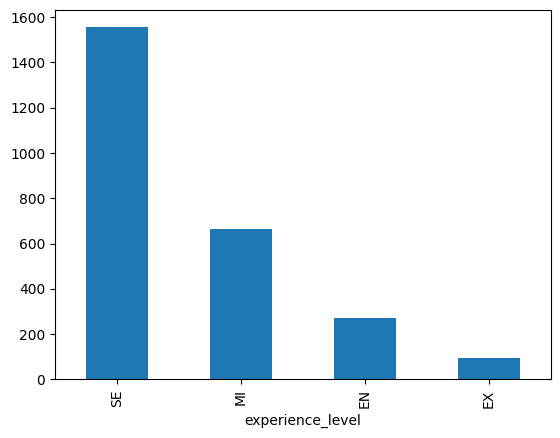

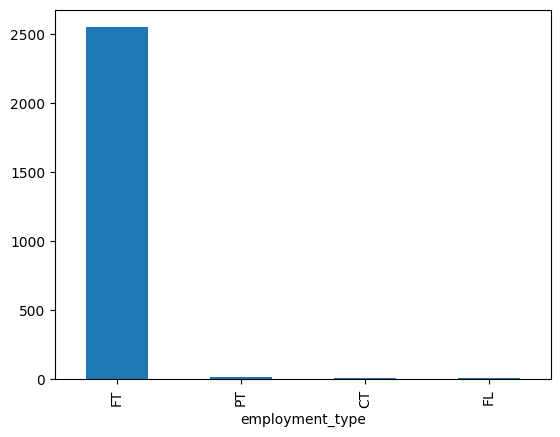

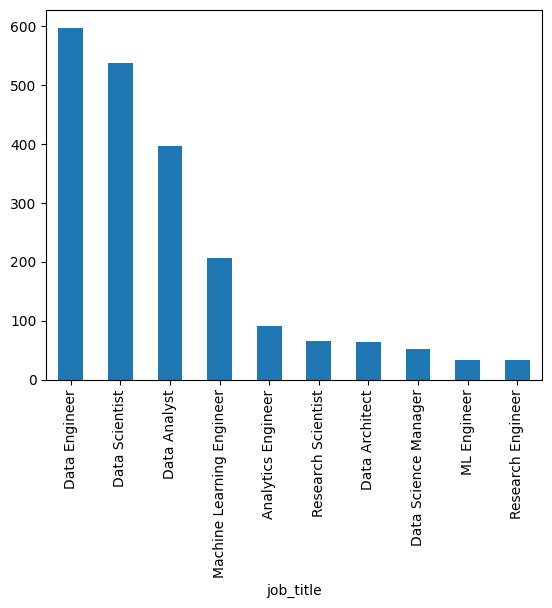

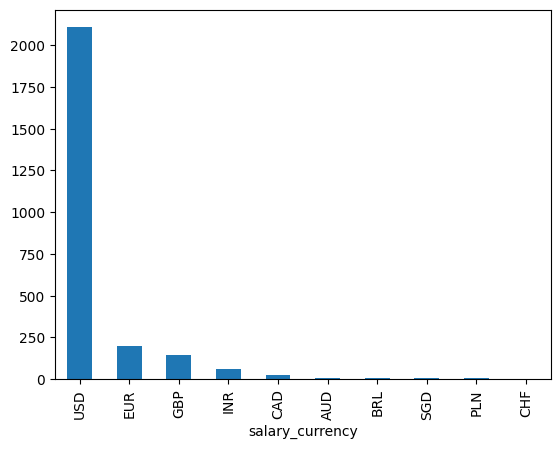

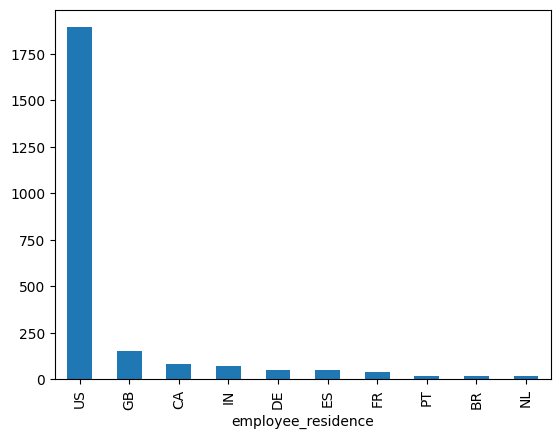

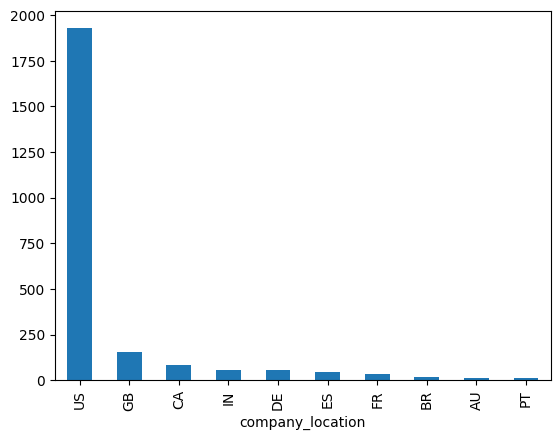

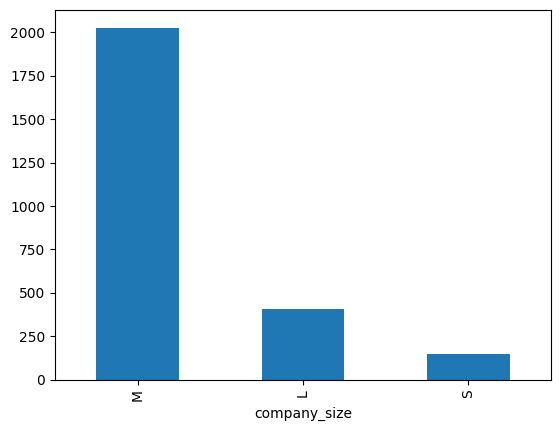

In [74]:
for col in df_text: 
    rs=df[col].value_counts(ascending=False).head(10).plot(kind="bar")
    plt.show()
    

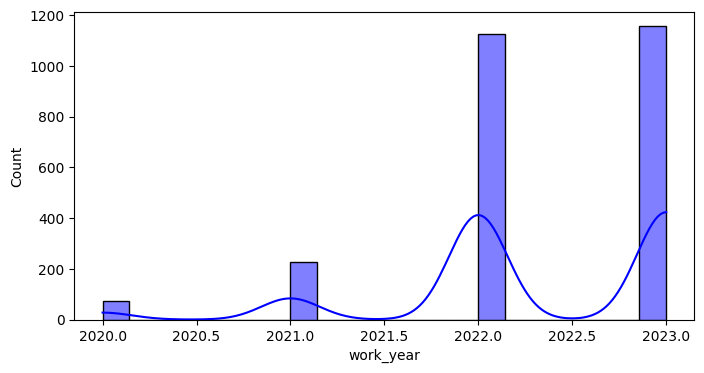

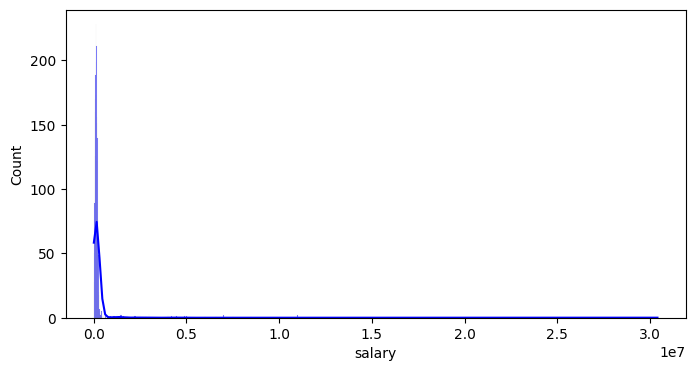

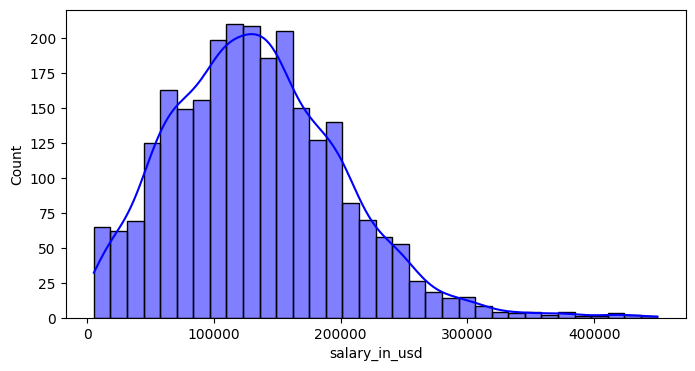

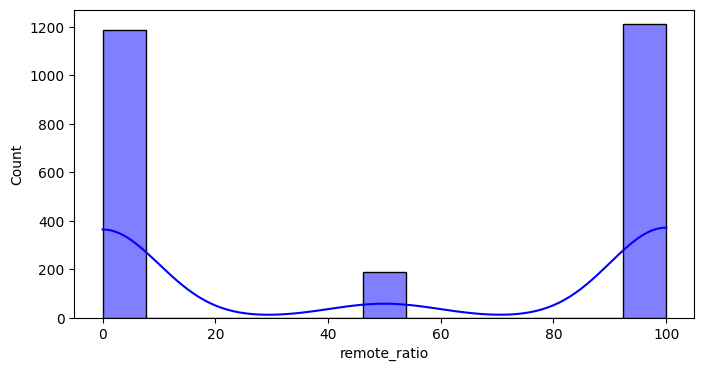

In [75]:
for col in df_num:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col , kde=True, color= "blue")

**Removes outliers**

In [76]:
def remove_outliers(df, column):
   
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    num_outliers = len(df) - len(df_filtered)
    print(f"\n--- Outlier Removal Summary for '{column}' ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Original rows: {len(df)}, Filtered rows: {len(df_filtered)}")
    print(f"Number of outliers removed: {num_outliers}")

    return df_filtered

In [77]:
for col in df_num: 
    df=remove_outliers(df,col)


--- Outlier Removal Summary for 'work_year' ---
Q1: 2022.00, Q3: 2023.00, IQR: 1.00
Lower Bound: 2020.50, Upper Bound: 2024.50
Original rows: 2584, Filtered rows: 2509
Number of outliers removed: 75

--- Outlier Removal Summary for 'salary' ---
Q1: 90000.00, Q3: 182750.00, IQR: 92750.00
Lower Bound: -49125.00, Upper Bound: 321875.00
Original rows: 2509, Filtered rows: 2425
Number of outliers removed: 84

--- Outlier Removal Summary for 'salary_in_usd' ---
Q1: 90000.00, Q3: 175100.00, IQR: 85100.00
Lower Bound: -37650.00, Upper Bound: 302750.00
Original rows: 2425, Filtered rows: 2416
Number of outliers removed: 9

--- Outlier Removal Summary for 'remote_ratio' ---
Q1: 0.00, Q3: 100.00, IQR: 100.00
Lower Bound: -150.00, Upper Bound: 250.00
Original rows: 2416, Filtered rows: 2416
Number of outliers removed: 0


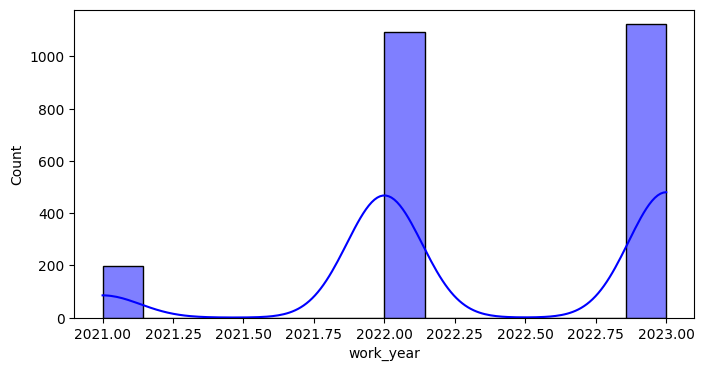

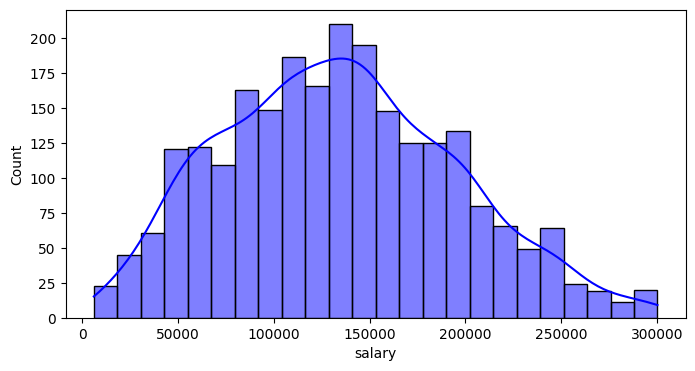

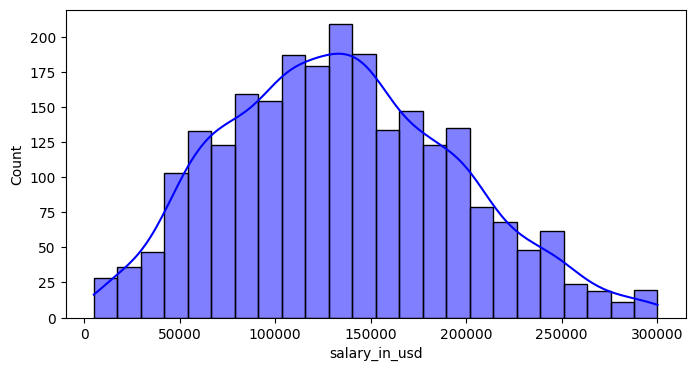

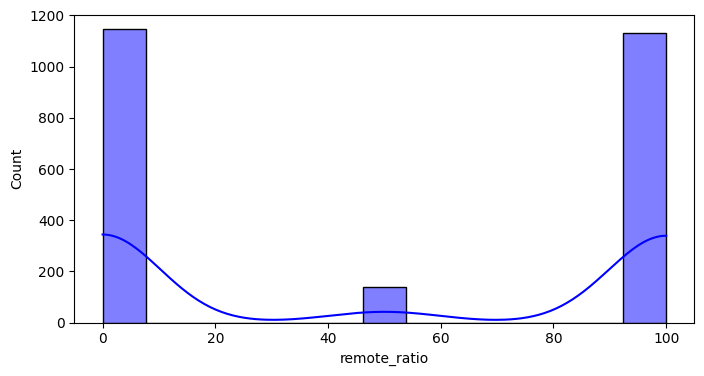

In [78]:
for col in df_num:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col , kde=True, color= "blue")
    

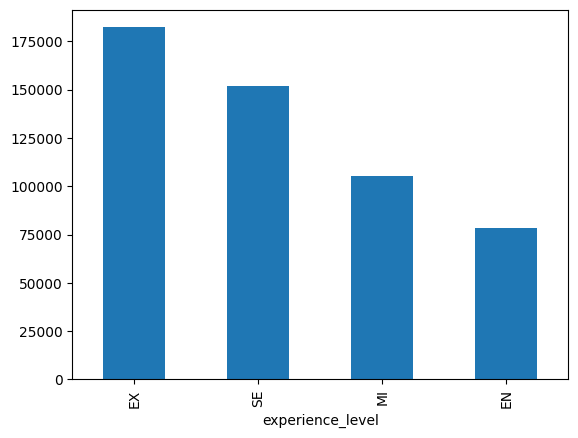

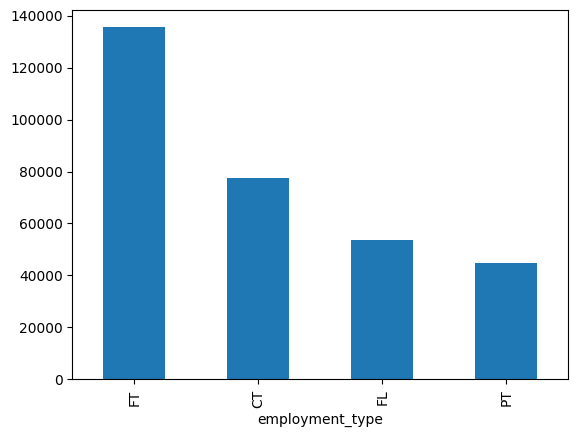

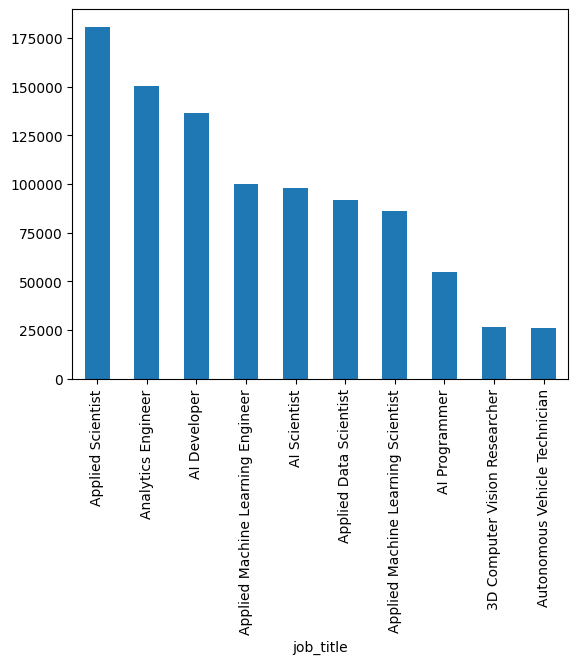

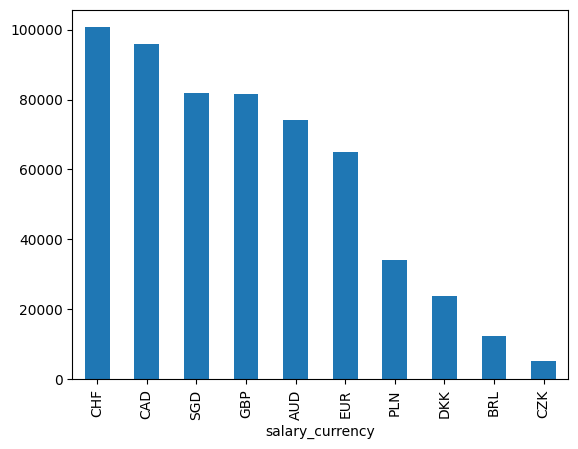

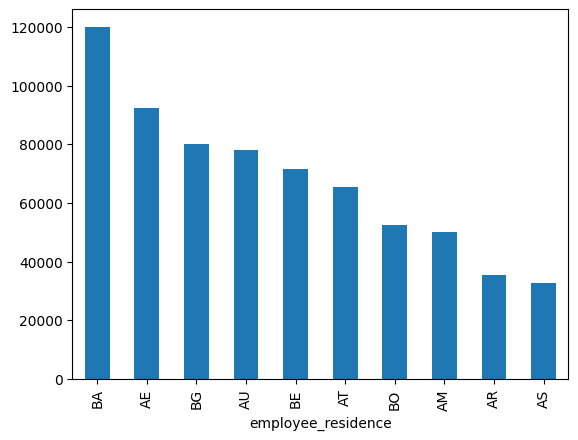

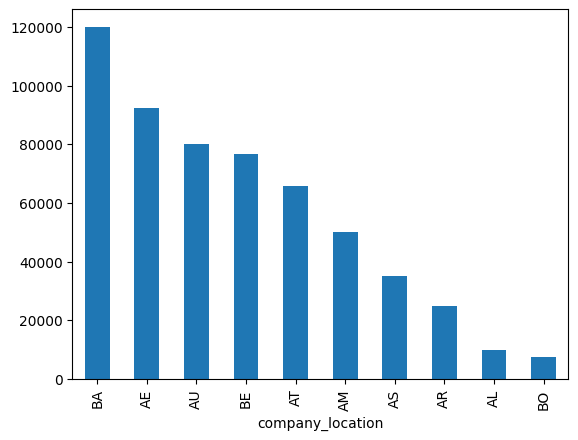

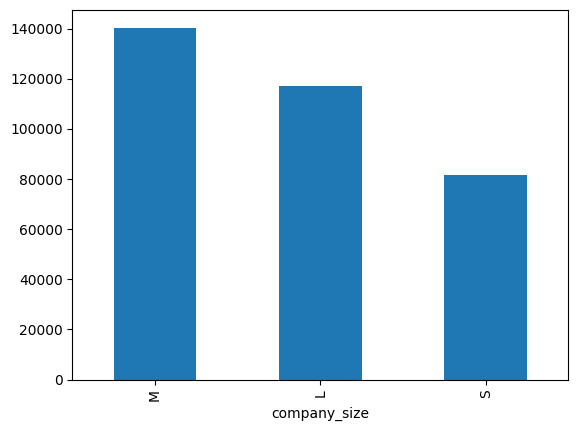

In [79]:
for col in df_text:
    
    df.groupby(col)["salary_in_usd"].mean().head(10).sort_values(ascending=False).plot(kind= "bar")
    plt.show()

In [80]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
scalar = StandardScaler()
le = LabelEncoder()

In [81]:
for col in df_text:
    df[col] = le.fit_transform(df[col])

In [82]:
df.corr()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
work_year,1.000000,0.158956,-0.000768,-0.020005,0.191258,0.209692,0.207750,0.186802,-0.227568,0.178792,0.174548
experience_level,0.158956,1.000000,-0.053206,0.025460,0.344363,0.203373,0.352783,0.233678,-0.038461,0.230525,0.070342
employment_type,-0.000768,-0.053206,1.000000,-0.066198,0.027722,-0.046535,0.014227,-0.018363,-0.023018,-0.005087,-0.052472
job_title,-0.020005,0.025460,-0.066198,1.000000,0.123164,-0.054582,0.124176,-0.051177,-0.053049,-0.064931,-0.012970
salary,0.191258,0.344363,0.027722,0.123164,1.000000,0.399172,0.983057,0.413251,-0.060258,0.406983,-0.010688
salary_currency,0.209692,0.203373,-0.046535,-0.054582,0.399172,1.000000,0.415221,0.693532,-0.046584,0.710370,0.125841
salary_in_usd,0.207750,0.352783,0.014227,0.124176,0.983057,0.415221,1.000000,0.409149,-0.072891,0.402904,-0.001541
employee_residence,0.186802,0.233678,-0.018363,-0.051177,0.413251,0.693532,0.409149,1.000000,-0.080082,0.938003,0.010051
remote_ratio,-0.227568,-0.038461,-0.023018,-0.053049,-0.060258,-0.046584,-0.072891,-0.080082,1.000000,-0.067892,-0.034193
company_location,0.178792,0.230525,-0.005087,-0.064931,0.406983,0.710370,0.402904,0.938003,-0.067892,1.000000,0.025619


## Data Preprocessing

In [83]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [84]:
x = df[['work_year', 'experience_level', 'job_title','employee_residence', 'company_location',]]
y = df['salary_in_usd']

In [85]:
x = scalar.fit_transform(x)

## Model Selection

In [86]:
from sklearn.model_selection import train_test_split,GridSearchCV
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2 ,random_state=42)

In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
lr = LinearRegression()
knr = KNeighborsRegressor()
dtr = DecisionTreeRegressor()
svr = SVR()

In [88]:
models = [lr,knr,dtr,svr]

In [89]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error

In [90]:
for model in models: 
    model.fit(xtrain,ytrain)
    m_pred = model.predict(xtest) 
    print(f"the mean absolute error is {mean_absolute_error(ytest,m_pred)} of {model}")
    print(f"the mean absolute error % is {mean_absolute_percentage_error(ytest,m_pred)} of {model}")
    print(f"the Root mean squared error is {np.sqrt(mean_squared_error(ytest,m_pred))} of {model}")

the mean absolute error is 41721.07063533142 of LinearRegression()
the mean absolute error % is 0.4293336755218058 of LinearRegression()
the Root mean squared error is 52466.60300512776 of LinearRegression()
the mean absolute error is 41223.43099173554 of KNeighborsRegressor()
the mean absolute error % is 0.42545968025511155 of KNeighborsRegressor()
the Root mean squared error is 52686.89699810422 of KNeighborsRegressor()
the mean absolute error is 38791.05140505377 of DecisionTreeRegressor()
the mean absolute error % is 0.37370612630038974 of DecisionTreeRegressor()
the Root mean squared error is 50274.20208089266 of DecisionTreeRegressor()
the mean absolute error is 50099.99226192744 of SVR()
the mean absolute error % is 0.5895121035737945 of SVR()
the Root mean squared error is 61898.7578856911 of SVR()


In [91]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(random_state=42)

In [92]:
rfr.fit(xtrain,ytrain)
y_pred = rfr.predict(xtest)
print(mean_absolute_error(ytest,y_pred))
print(mean_absolute_percentage_error(ytest,y_pred))
print(np.sqrt(mean_squared_error(ytest,y_pred)))

37213.32481421006
0.3596419892019785
47470.124987970936


In [93]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(100,200,20):
    xgb = GradientBoostingRegressor(n_estimators=i,max_depth=3)
    xgb.fit(xtrain,ytrain)
    m_pred = xgb.predict(xtest) 
    print(f"the mean absolute error is {mean_absolute_error(ytest,m_pred)} of xgb")
    print(f"the mean absolute error % is {mean_absolute_percentage_error(ytest,m_pred)} of xgb")
    print(f"the Root mean squared error is {np.sqrt(mean_squared_error(ytest,m_pred))} of xgb")

the mean absolute error is 35822.95584997583 of xgb
the mean absolute error % is 0.33224423308014644 of xgb
the Root mean squared error is 45587.372826250474 of xgb
the mean absolute error is 35664.34370279789 of xgb
the mean absolute error % is 0.32913525269305355 of xgb
the Root mean squared error is 45443.765036427496 of xgb
the mean absolute error is 35582.831498383304 of xgb
the mean absolute error % is 0.32761703204708087 of xgb
the Root mean squared error is 45402.02777975636 of xgb
the mean absolute error is 35532.60319542531 of xgb
the mean absolute error % is 0.3286427497464 of xgb
the Root mean squared error is 45338.77285231479 of xgb
the mean absolute error is 35416.78692947313 of xgb
the mean absolute error % is 0.32489963565074753 of xgb
the Root mean squared error is 45268.78606450203 of xgb


Gradient Boosting Regressor is most suitable model 